In [1]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from scdepth import pl, fn, fit
from scipy import stats
import glob, os

In [2]:
cdf = pd.read_csv('../data/cohort.csv')
adf = pd.read_csv('../data/cohort_annotations.csv')
tmap = {(c.group, c.subgroup):c for c in cdf.itertuples()}
cdf = cdf.copy()
adf = adf.copy()
cdf = cdf.merge(adf, left_on=['group','subgroup'], right_on=['group','subgroup'], how='left')



In [3]:
dfs = []
rows  = []
for i, r in cdf.iterrows():
    ch = r.dataset
    if 'visium' in ch or 'flex' in ch:
        continue
    bdf = pd.read_csv(f'../{ch}/{r["sample"]}/scdepth_fit_baseline.txt', sep='\t')
    bdf['group'] = r['group']
    bdf['color'] = r['color']
    bdf['subgroup'] = r['subgroup']
    bdf['dataset'] = r['dataset']
    bdf['group_title'] = r['group_title']
    bdf['subgroup_title'] = r['subgroup_title']
    bdf['title'] = r['title']



    
    dfs.append(bdf)
df = pd.concat(dfs)

Brain N = 7
    Spliced 2.26 fraction of molecules = 0.020
    Unspliced 1.10 fraction of molecules = 0.684
    Ambiguous 0.77 fraction of molecules = 0.290
Colon N = 6
    Spliced 2.30 fraction of molecules = 0.171
    Unspliced 0.95 fraction of molecules = 0.110
    Ambiguous 0.91 fraction of molecules = 0.710
Heart N = 13
    Spliced 2.39 fraction of molecules = 0.233
    Unspliced 1.08 fraction of molecules = 0.200
    Ambiguous 0.83 fraction of molecules = 0.546
Melanoma N = 4
    Spliced 2.19 fraction of molecules = 0.377
    Unspliced 1.09 fraction of molecules = 0.168
    Ambiguous 0.68 fraction of molecules = 0.440
OvaryCA_CD45m N = 19
    Spliced 1.20 fraction of molecules = 0.197
    Unspliced 1.02 fraction of molecules = 0.272
    Ambiguous 0.92 fraction of molecules = 0.535
OvaryCA_CD45p N = 20
    Spliced 1.57 fraction of molecules = 0.166
    Unspliced 1.06 fraction of molecules = 0.283
    Ambiguous 0.86 fraction of molecules = 0.545
Spliced 5.95 x 10^-13 Median Ratio =

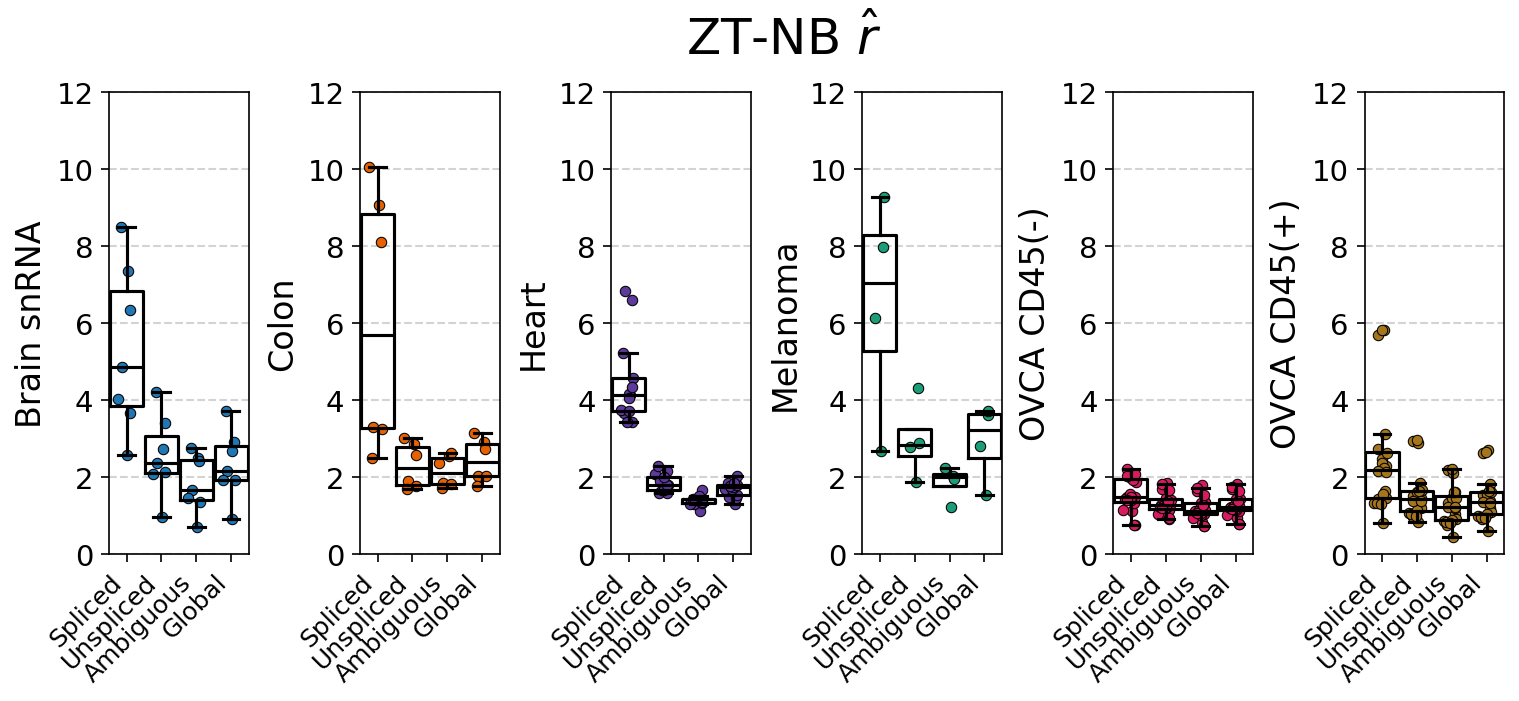

In [4]:
from scipy.stats import wilcoxon
fig, axs = pl.figax(1, 6, w=2, h=4)
fig.subplots_adjust(wspace=0.8)
sgs = {}
labs = 'Spliced', 'Unspliced', 'Ambiguous', 'Global'

colors = [
    "#1F77B4",
    "#E66100",
    "#5D3A9B",
    "#1B9E77",
    "#D81B60",
    "#A6761D",
    "#666666",
]
for ax, (g, d), c in zip(axs, df.groupby('group'), colors):

    for i, k in enumerate(('spliced','unspliced','ambiguous', 'global')):       
        kk = f'{k}_ztnb_rhat' if k != 'global' else 'ztnb_rhat'
        sgs[d['subgroup_title'].values[0]] = d['color'].values[0]
        pl.jitter_box(ax, i, d[kk], color=c, s=25, edgecolor='k', lw=0.5, blw=1.5, mlw=1.5, wlw=1.5, plw=1.5)
        sgs.setdefault(k, []).extend(d[kk].values)
        
    ax.set_xticklabels(labs, rotation=45, ha='right', fontsize=12)     
    #ax.set_title(k.title(), fontsize=18)
    ax.set_ylim(0, 12)
    ax.tick_params(axis='both', which='both', length=4)
    ax.tick_params(axis='y', labelsize=14)    
    ax.grid(axis='y', color='lightgray', ls='--', lw=1, which='both')
    ax.set_axisbelow(True)
    ax.set_ylabel(f"{d['group_title'].values[0]}", fontsize=16)
    print(f'{g} N = {len(d)}')
    
    for k in ('spliced','unspliced','ambiguous'):
        ratio = np.median(d[f'{k}_ztnb_rhat'] / d['ztnb_rhat'])
        frac = np.median(d[f'{k}_molecules'] / d['molecules'])
        print(f'    {k.title()} {ratio:.2f} fraction of molecules = {frac:.3f}')



for k in ('spliced','unspliced','ambiguous'):
    pval, ratio = wilcoxon(sgs[k], sgs['global']).pvalue, np.median(np.divide(sgs[k], sgs['global']))
    base, exp = f"{pval:.2e}".split('e')
    
    print(f'{k.title()} {base} x 10^{exp} Median Ratio = {ratio:.3f}')
#axs[0].set_ylabel(r'$\hat{r}$', fontsize=24)

fig.suptitle(r'ZT-NB $\hat{r}$', fontsize=24, y=1.01)
fig.savefig('../Figures/Figure S7 Class rhat.svg', bbox_inches='tight')


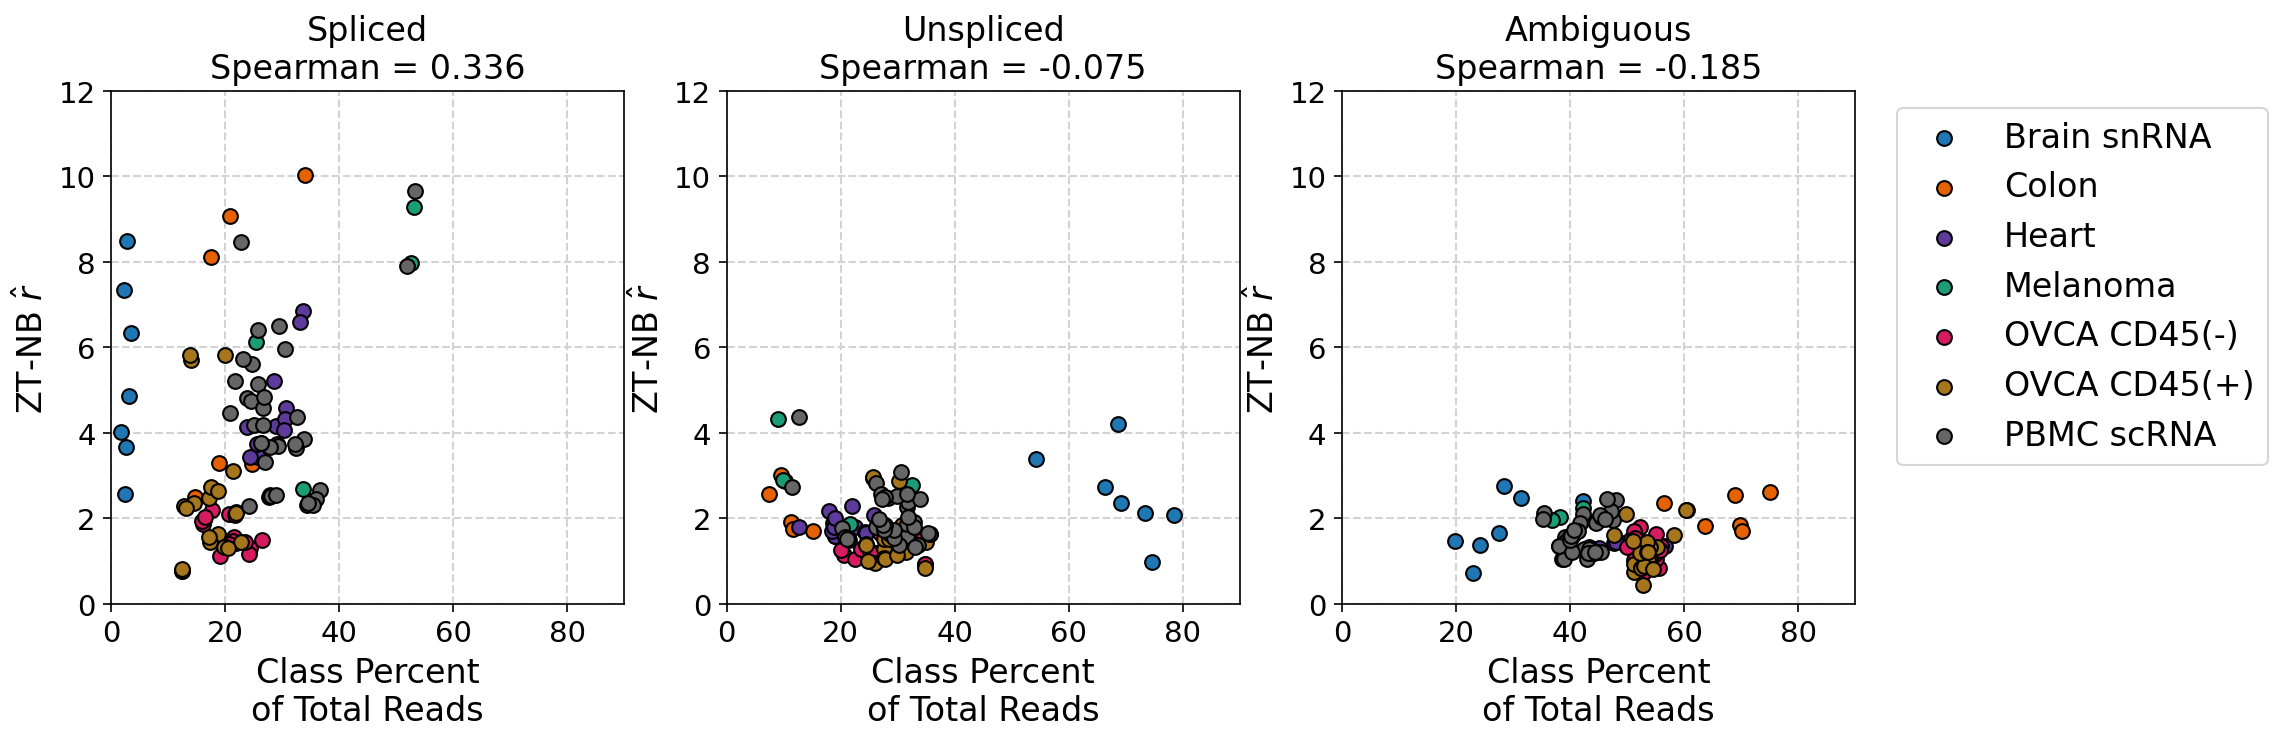

In [35]:
from scipy.stats import spearmanr
fig, axs = pl.figax(1, 3, s=5)
xp = {}
yp = {}
seen = set()
for (g, d), color in zip(df.groupby('group'), colors):
    for s in d.itertuples():
        for i, k in enumerate(('spliced','unspliced','ambiguous')):       
            p =  100*getattr(s, f'{k}_reads') / s.reads
            ll = d['group_title'].values[0] if (k, d['group_title'].values[0]) not in seen else '_'
            axs[i].scatter(p, getattr(s, f'{k}_ztnb_rhat'), s=50, color=color, edgecolor='k', 
                           label=('_' if ll in seen else ll))
            seen.add((k, d['group_title'].values[0]))
            xp.setdefault(k, []).append(p)
            yp.setdefault(k, []).append(getattr(s, f'{k}_ztnb_rhat'))

for i, (k, ax) in enumerate(zip(('spliced','unspliced','ambiguous'), axs)):
    res = spearmanr(xp[k], yp[k]).statistic
    ax.set_box_aspect(1)
    ax.set_title(f'{k.title()}\nSpearman = {res:.3f}', fontsize=16)
    ax.set_ylabel(r'ZT-NB $\hat{r}$', fontsize=16)
    ax.set_xlabel('Class Percent\nof Total Reads', fontsize=16,)
    ax.tick_params(axis='both', which='both', length=4)
    ax.tick_params(axis='both', labelsize=14)    
    ax.grid(axis='both', color='lightgray', ls='--', lw=1, which='both')
    ax.set_ylim(0, 12)
    ax.set_xlim(0, 90)
    ax.set_axisbelow(True)
axs[-1].legend(loc = 'upper left', bbox_to_anchor=(1.05, 1), fontsize=16)


Spliced wilcoxon = 6.36 x 10^-19 Median Diff = 14.278
Unspliced wilcoxon = 1.99 x 10^-05 Median Diff = -0.770
Ambiguous wilcoxon = 5.84 x 10^-19 Median Diff = -5.747


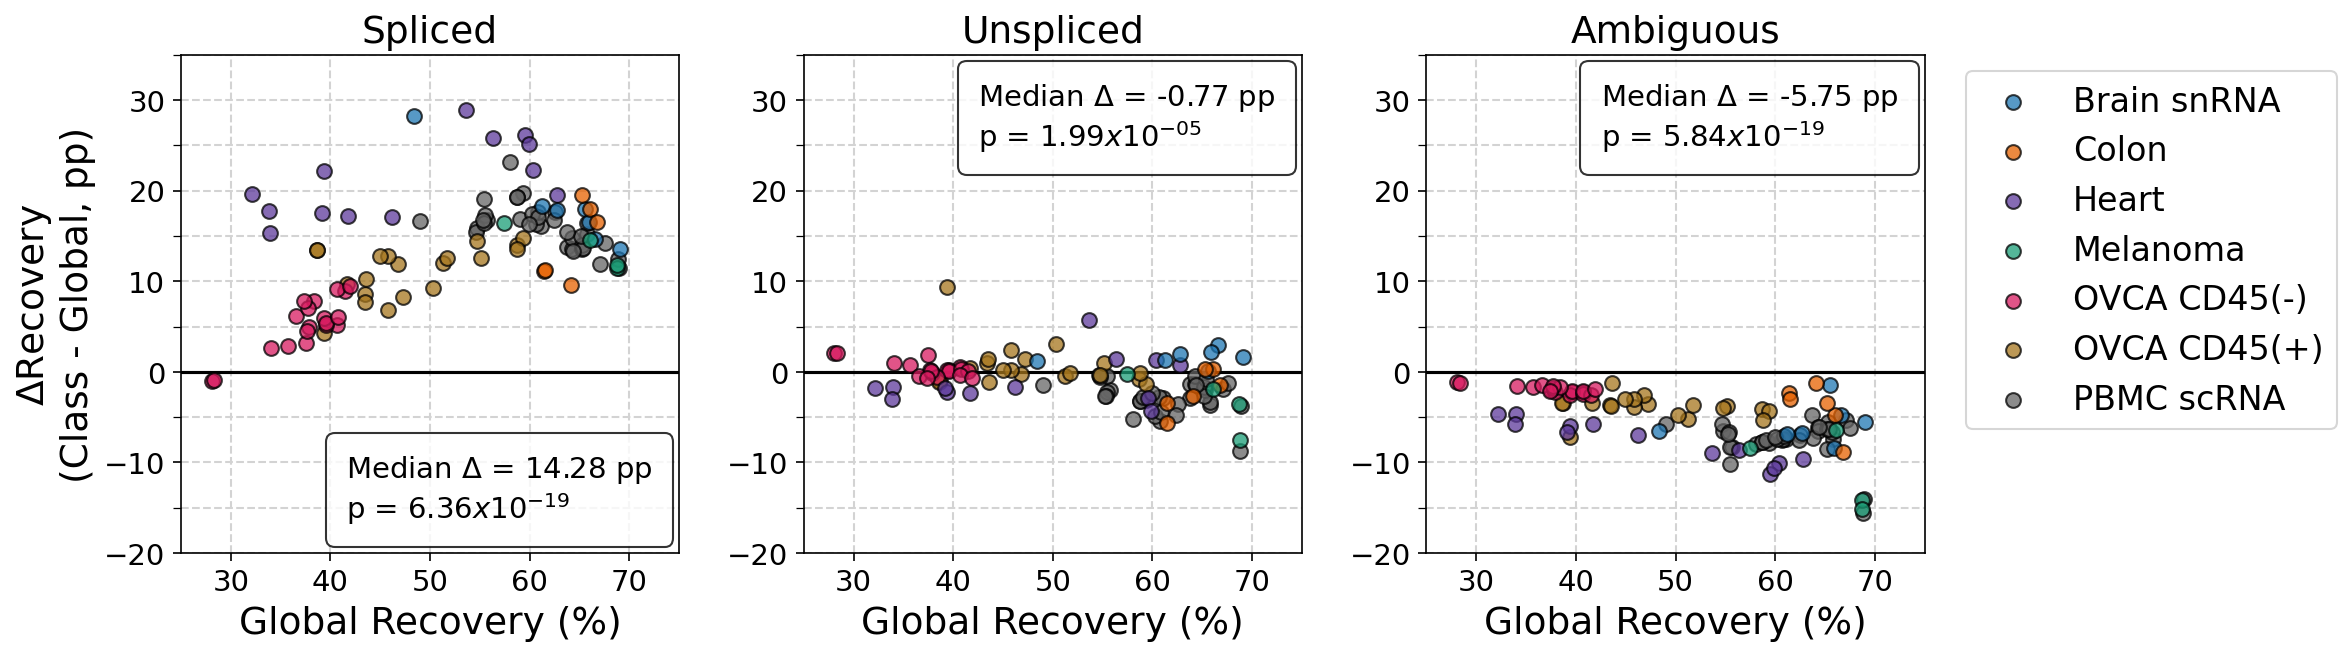

In [5]:
fig, axs = pl.figax(1, 3, s=5)
fig.subplots_adjust(wspace=0.25)
import matplotlib.offsetbox as offsetbox


class_recs = {}
global_recs = []
for (g, d), color in zip(df.groupby('group'), colors):
    grecs = []
    crecs = [[], [], []]
    for s in d.itertuples():
        ff = fit.NBLibFit(phat=s.ztnb_phat, rhat=s.ztnb_rhat, L=s.nb_lib_L)
        grec = ff.predict_recovery(s.reads)
        grecs.append(grec)
        for i, k in enumerate(('spliced','unspliced','ambiguous')):       
            ff = fit.NBLibFit(phat=getattr(s, f'{k}_ztnb_phat'), 
                              rhat=getattr(s, f'{k}_ztnb_rhat'), 
                              L=getattr(s, f'{k}_nb_lib_L'))
            crec = ff.predict_recovery(getattr(s, f'{k}_reads'))
            crecs[i].append(crec)

    global_recs.extend(grecs)
    
    for recs, k, ax in zip(crecs, ('spliced','unspliced','ambiguous'), axs):
        ax.scatter(grecs, np.subtract(recs, grecs), s=50, color=color, edgecolor='k', lw=1, alpha=0.75, label=d['group_title'].values[0], 
                   zorder=(100-len(d)))
        class_recs.setdefault(k, []).extend(recs)
        
           
for k, ax in zip(('spliced','unspliced','ambiguous'), axs):
    
    ax.set_box_aspect(1)
    ax.set_ylim(-10, 30)
    ax.set_yticks(np.arange(-20, 40, 10))
    ax.set_yticks(np.arange(-20, 40, 5), minor=True)
    ax.set_xlim(25, 75)
    ax.tick_params(axis='both', which='both', length=4)
    ax.tick_params(axis='both', labelsize=14)    
    ax.grid(axis='both', color='lightgray', ls='--', lw=1, which='both')
    ax.set_axisbelow(True)
    ax.set_xlabel('Global Recovery (%)', fontsize=18)
    ax.axhline(0, ls='-', color='k', lw=1.5, zorder=1)
    ax.set_title(k.title(), fontsize=18)

axs[0].set_ylabel(r'$\Delta{\mathrm{Recovery}}$' + '\n(Class - Global, pp)', fontsize=18)
    
axs[-1].legend(loc = 'upper left', bbox_to_anchor=(1.05, 1), fontsize=16)


for ax, k, bloc in zip(axs, ('spliced','unspliced','ambiguous'), ('lower right', 'upper right', 'upper right')):
    pval, ratio = wilcoxon(class_recs[k], global_recs).pvalue, np.median(np.subtract(class_recs[k], global_recs))
    base, exp = f"{pval:.2e}".split('e')
    ob = offsetbox.AnchoredText(f'Median $\\Delta$ = {ratio:.2f} pp\np = ${base} x 10^{{{exp}}}$', loc=bloc, frameon=True, prop={'size': 14})
    ob.patch.set(boxstyle='round', facecolor='white', alpha=0.8) 
    ax.add_artist(ob)
    
    print(f'{k.title()} wilcoxon = {base} x 10^{exp} Median Diff = {ratio:.3f}')
fig.savefig('../Figures/Figure S7 Class Recovery.svg', bbox_inches='tight')


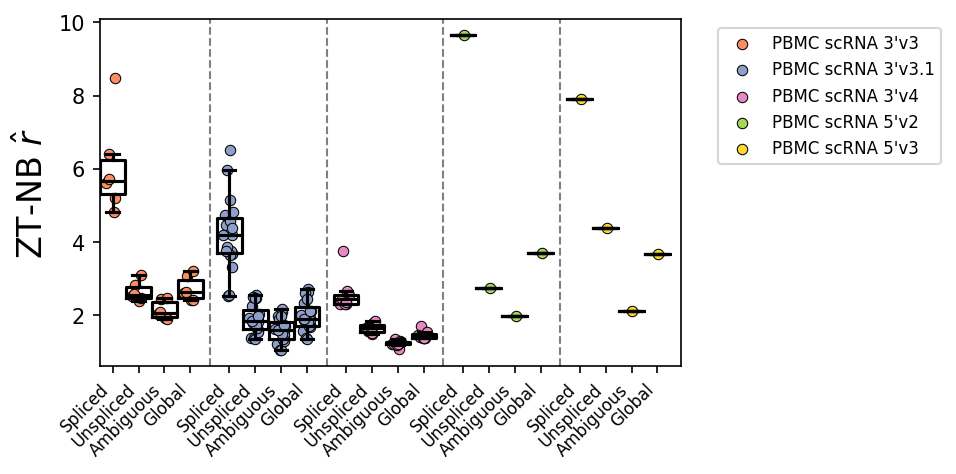

In [6]:

fig, ax = pl.figax(1, 1, h=3, w=5)
fig.subplots_adjust(wspace=0.25)
import matplotlib.offsetbox as offsetbox


sdf = df[df['group'].str.contains('PBMC')]
idx = 0
class_recs = {}
global_recs = []
xl = []
seen = set()
xt = []
for (g, d) in sdf.groupby('subgroup'):
    ti = d['title'].values[0]
    for i, k in enumerate(('spliced','unspliced','ambiguous', 'global')):       
        kk = f'{k}_ztnb_rhat' if k != 'global' else 'ztnb_rhat'
        lab = '_'
        if ti not in seen:
            lab = ti
            seen.add(ti)
        pl.jitter_box(ax, idx, d[kk], color=d['color'].values[0], s=25, edgecolor='k', lw=0.5, 
                      blw=1.5, mlw=1.5, wlw=1.5, plw=1.5, label=lab)
        xl.append(k.title())
        xt.append(idx)
        idx += 1
        
    if idx < 22:
        ax.axvline(idx - 0.25, ls='--', color='gray', lw=1)

    idx += 0.5
ax.set_xlim(-0.5, idx - 0.6)
ax.set_xticks(xt)
ax.set_xticklabels(xl, rotation=45, ha='right', fontsize=8)
ax.legend(loc = 'upper left', bbox_to_anchor=(1.05, 1), fontsize=8)
ax.set_ylabel('ZT-NB $\\hat{r}$', fontsize=16)

fig.savefig('../Figures/Figure S7 PBMC rhat.svg', bbox_inches='tight')
